In [1]:
import os
import sys
import numpy
import pandas
from datetime import datetime, timedelta
import pytz
import geopandas
import shapely
from shapely import wkb, wkt
import pyproj

sys.path.insert(1, os.path.abspath(".."))
import nestedgrid
import mortoncurve
import vectorstore2
import time

#import contextily
#import sqlite3
#import pysqlite3 as sqlite3
#import spatialite
"""
# sudo apt-get install libsqlite3-mod-spatialite
# pip install spatialite
import spatialite
with spatialite.connect('sl_temp.db') as db:
    print(db.execute('SELECT spatialite_version()').fetchone()[0])
"""

from functools import partial
import json

import matplotlib
matplotlib.use('Agg')
%matplotlib inline
import matplotlib.pyplot as plt

# Initialize a dataset

In [2]:
# %%time
# dataset = 'powerlines'

# dt_col = 'timestamp'
# geom_col = 'geometry'  # Needs to be called 'geometry'
# id_col = 'geom_id'

# intersection_policy = 'original' #'original' #'cut' # 'both'

# # temporal_keys = [] #['year']
# # temporal_partitions = [] #['year']

# max_level = 12
# target_level = 8
# max_depth = 4

# # spatial_partition_levels = [4, 6]
# # filter_key_levels = [10, 12, 14]

# # numeric_layers = ['Voltage']
# # timestamp_layers = ['timestamp']
# # categorical_layers = []
# # percentiles = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]

# csv_path = '/data/vector/powerlines/Vector_Data_Output.csv'
# df = pandas.read_csv(csv_path)
# df['geometry'] = df['Region'].apply(wkt.loads)
# gdf = geopandas.GeoDataFrame(df, geometry='geometry', crs='4326')
# gdf.index.name = 'geom_id'
# gdf = gdf.reset_index()
# gdf = gdf.rename(columns={'Value': 'Voltage'})
# gdf.loc[gdf['Voltage']==-999999, 'Voltage'] = numpy.nan
# gdf['timestamp'] = gdf['Time'].apply(lambda x: datetime.strptime(x, "%Y-%m-%dT%H:%M:%SZ").replace(tzinfo=pytz.utc))
# gdf = gdf[['geom_id', 'DataSet', 'timestamp', 'Voltage', 'Unit', 'geometry']]
# gdf

# # Create or initialize an existing GeoDN vectorstore
# vs = vectorstore2.Vectorstore(
#     dataset=dataset,
#     dt_col=dt_col,
#     geom_col=geom_col,
#     id_col=id_col,
#     target_level=target_level,
#     max_depth=max_depth,
#     intersection_policy=intersection_policy,
#     verbose=True,
# )

In [3]:
%%time
dataset = 'kaggle_wildfire'

dt_col = 'timestamp'
geom_col = 'geometry'  # Needs to be called 'geometry'
id_col = 'FOD_ID' #'geom_id'

intersection_policy = 'original' #'original' #'cut' # 'both'

# temporal_keys = [] #['year']
# temporal_partitions = [] #['year']

target_level = 10
max_depth = 10
target_rows = 100000

# numeric_layers = ['Voltage']
# timestamp_layers = ['timestamp']
# categorical_layers = []
# percentiles = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]

geoparquet_path = '/data/vector/kaggle_wildfire/gdf_kaggle_wildfire.parquet'

# parquet_path = '/data/vector/kaggle_wildfire/kaggle_wildfire.parquet'
# df = pandas.read_parquet(parquet_path)

# def make_geometry_table(df):
#     # FIRE_SIZE is in acres. 
#     # So let's approximate the geometry by buffereing the point to the area of the FIRE_SIZE (ellipse in WGS84)
#     gdf = geopandas.GeoDataFrame(df, geometry=geopandas.points_from_xy(df.LONGITUDE, df.LATITUDE), crs="EPSG:4326")
#     # Switch projection to Pseudo Merkator (almost conformal projection to preserve angles)
#     gdf = gdf.to_crs("EPSG:3857")
#     # Mercator scale factor (for areas use the square)
#     scale_factor = numpy.cos(gdf['LATITUDE'] / 180. * numpy.pi)
#     # Acres to meters
#     gdf['radius'] = numpy.sqrt(gdf['FIRE_SIZE'] * 4046.8564224 / numpy.pi) / scale_factor
#     # Buffer to create a circle
#     gdf['geometry'] = gdf['geometry'].buffer(gdf['radius'])
#     del gdf['radius']
#     # Switch back to WGS84
#     gdf = gdf.to_crs("EPSG:4326")
#     return gdf

# gdf = make_geometry_table(df)
# gdf.to_parquet(geoparquet_path)

# gdf = geopandas.read_parquet(geoparquet_path)
# gdf.tail(2)

# Create or initialize an existing GeoDN vectorstore
vs = vectorstore2.Vectorstore(
    dataset=dataset,
    dt_col=dt_col,
    geom_col=geom_col,
    id_col=id_col,
    target_level=target_level,
    max_depth=max_depth,
    intersection_policy=intersection_policy,
    verbose=True,
)

CPU times: total: 0 ns
Wall time: 1.28 ms


In [4]:
# %%time
# dataset = 'carbon_storage'

# dt_col = 'timestamp'
# geom_col = 'geometry'  # Needs to be called 'geometry'
# id_col = 'geom_id'

# intersection_policy = 'original' #'original' #'cut' # 'both'

# # temporal_keys = [] #['year']
# # temporal_partitions = [] #['year']

# target_level = 13
# max_depth = 0
# target_rows = 100000

# # numeric_layers = ['Voltage']
# # timestamp_layers = ['timestamp']
# # categorical_layers = []
# # percentiles = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]

# csv_path = '/data/vector/carbon_storage/carbon_storage.csv'
# # df = pandas.read_csv(csv_path)
# # df['geometry'] = df['Region'].apply(wkt.loads)
# # gdf = geopandas.GeoDataFrame(df, geometry='geometry', crs='4326')
# # gdf.index.name = 'geom_id'
# # gdf = gdf.reset_index()
# # gdf = gdf.rename(columns={'Value': 'Voltage'})
# # gdf.loc[gdf['Voltage']==-999999, 'Voltage'] = numpy.nan
# # gdf['timestamp'] = gdf['Time'].apply(lambda x: datetime.strptime(x, "%Y-%m-%dT%H:%M:%SZ").replace(tzinfo=pytz.utc))
# # gdf = gdf[['geom_id', 'DataSet', 'timestamp', 'Voltage', 'Unit', 'geometry']]
# # gdf

# def process(i, chunk, verbose=False):
#     loop_start = time.time()
#     gdf = prepare_data(chunk)
#     vs.partial_upload(gdf)
#     print('Upload time for chunk', i, round(time.time()-loop_start, 3), 'seconds')
#     return gdf, vs

# def prepare_data(chunk):
#     if verbose:
#         stopwatch_start = time.time()
#     # Read the geometry using wkt and cast to GeoDataFrame
#     chunk['geometry'] = chunk['st_astext'].apply(wkt.loads)
#     del chunk['st_astext']
#     gdf = geopandas.GeoDataFrame(chunk, geometry='geometry', crs='4326')

#     # Timestamp in datetime format
#     gdf['timestamp'] = gdf['timestamp'].apply(lambda x: datetime.fromtimestamp(x).replace(tzinfo=pytz.utc)) 

#     # fid does not seem to be unique, so generate a unique id
#     gdf.index.name = 'geom_id'
#     gdf = gdf.reset_index()
    
#     # We want to use borocode as categorical variable, so cast to string
#     gdf['borocode'] = gdf['borocode'].astype(str)
#     if verbose:
#         print('Time for preparing data', round(time.time()-stopwatch_start, 3), 'seconds')
    
#     return gdf

# # Create or initialize an existing GeoDN vectorstore
# vs = vectorstore2.Vectorstore(
#     dataset=dataset,
#     dt_col=dt_col,
#     geom_col=geom_col,
#     id_col=id_col,
#     target_level=target_level,
#     max_depth=max_depth,
#     intersection_policy=intersection_policy,
#     verbose=True,
# )

# # chunksize = 10**6 #10**7
# # verbose=True
# # with pandas.read_csv(csv_path, chunksize=chunksize) as reader:
# #     for i, chunk in enumerate(reader):
# #         gdf, vs = process(i, chunk)
# #         # if i>0:
# #         #     break


# Chunked successive ingestion

In [4]:
gdf_complete = geopandas.read_parquet(geoparquet_path)
gdf_complete.tail(2)

,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,LONGITUDE,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,timestamp,geometry
1880463,1831008,300251694,SFO-2015TXLFDX594491,NONFED,ST-NASF,ST/C&L,USTXTXS,Texas A & M Forest Service,TXLFDX,Local Fire Department,...,-94.947366,14.0,MISSING/NOT SPECIFIED,TX,Gregg,183,Gregg,b'\x00\x01\xad\x10\x00\x00\x1cv\x95\xa4\xa1\xb...,2015-12-31 00:00:00+00:00,"POLYGON ((-94.94717 32.43941, -94.94718 32.439..."
1880464,1801139,300213917,W-688210,FED,DOI-WFMI,BIA,USNMZUA,Zuni Agency,NMZUA,Zuni Agency,...,-108.782890,2.0,BIA,NM,None,None,None,b'\x00\x01\xad\x10\x00\x00`\x97\xa8\xde\x1a2[\...,2015-12-31 00:00:00+00:00,"POLYGON ((-108.78267 35.08119, -108.78268 35.0..."


In [5]:
%%time
n_chunks = 6
for i, chunk in enumerate(numpy.array_split(gdf_complete, n_chunks)):
    print('Chunk', i)
    vs.partial_upload(chunk, target_rows)

C:\Users\2D1245897\software\myenv\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\2D1245897\software\myenv\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\2D1245897\software\myenv\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kwds)
C:\Users\2D1245897\software\myenv\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'GeoDataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'GeoDataFrame.transpose' instead.
  return bound(*args, **kw

Chunk 0
len(gdf_unique)     313411
Python int too large to convert to C long
Failed to use numpy due to large integers. Switching to pandas
Time for initialization (A) in seconds 28.988
gdf_head   313411
gdf_target 311783
gdf_tree   1628
depth 1
depth 2
depth 3
depth 4
depth 5
depth 6
depth 7
depth 8
depth 9
depth 10
Time for recursive BFS (B) in seconds 0.722
Python int too large to convert to C long
failed to use numpy due to large integers. Switching to pandas
Time for finalizing gdf_concat (C) in seconds 21.201
Python int too large to convert to C long
failed to use numpy due to large integers. Switching to pandas
Time for finalizing gdf_target (D) in seconds 21.206
Time for creating df_idx (E) in seconds 14.387
Number of partitions suggested 4
Chunk 1
len(gdf_unique)     313411
Time for initialization (A) in seconds 3.312
gdf_head   313411
gdf_target 311711
gdf_tree   1700
depth 1
depth 2
depth 3
depth 4
depth 5
depth 6
depth 7
depth 8
depth 9
depth 10
Time for recursive BFS (B) i

In [5]:
%%time
vs.repartition()

debug df_source_partitions   partition  partition_level
0       0q0                1
1      0q00                2
2     0q003                3
3    0q0032                4
4    0q0033                4
5   0q00322                5
6   0q00323                5
7  0q003231                6
level 1
source_partition     target_partition     records stay         records move        
0q0                  0q003231             477473               0
0q0                  0q00322              477473               0
0q0                  0q00323              477473               0
0q0                  0q0032               477473               0
0q0                  0q0033               477473               0
0q0                  0q003                477473               12
0q0                  0q00                 477461               225128
level 2
source_partition     target_partition     records stay         records move        
0q00                 0q003231             315162               0
0q

In [6]:
%%time
partition = '0q003231'
filepath = os.path.join(vs.parquet_directory, partition+'.parquet')
gdf_file = geopandas.read_parquet(filepath)
gdf_file.tail(2)

CPU times: total: 1.91 s
Wall time: 2.37 s


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,timestamp,geometry,q_key
425451,1849639,300276524,SFO-2015FLFLS2015061167,NONFED,ST-NASF,ST/C&L,USFLFLS,Florida Forest Service,FLFLS,Florida Forest Service,...,8.0,PRIVATE,FL,Suwannee,121,Suwannee,b'\x00\x01\xad\x10\x00\x00\x1c\xf4lV}\xb6T\xc0...,2015-12-31 00:00:00+00:00,"POLYGON ((-82.85103 30.16870, -82.85103 30.168...",0q003231120301221
425452,1837358,300259980,SFO-2015GAGAS-FY2016-Coffee-010,NONFED,ST-NASF,ST/C&L,USGAGAS,Georgia Forestry Commission,GAGAS,Georgia Forestry Commission,...,7.0,STATE,GA,Coffee,069,Coffee,b'\x00\x01\xad\x10\x00\x00\xcct\x8e\x85\x11\xb...,2015-12-31 00:00:00+00:00,"POLYGON ((-82.81353 31.48414, -82.81353 31.484...",0q003231122321231330032


CPU times: total: 406 ms
Wall time: 738 ms


,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,...,OWNER_CODE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME,Shape,timestamp,geometry,q_key
4108,1829495,300249291,SFO-2015TNTNS15-H0213,NONFED,ST-NASF,ST/C&L,USTNTNS,Tennessee Division of Forestry,TNTNS,Tennessee Division of Forestry,...,8.0,PRIVATE,TN,LAWRENCE,099,Lawrence,b'\x00\x01\xad\x10\x00\x00\x00\xbe\xdb\xbcq\xd...,2015-11-27 00:00:00+00:00,"POLYGON ((-87.42854 35.24497, -87.42854 35.244...",0q0032312220322100203
4109,1812993,300228944,SFO-2015TNTNS15-H0219,NONFED,ST-NASF,ST/C&L,USTNTNS,Tennessee Division of Forestry,TNTNS,Tennessee Division of Forestry,...,8.0,PRIVATE,TN,HICKMAN,081,Hickman,b'\x00\x01\xad\x10\x00\x00x\xc5S\x8f4\xddU\xc0...,2015-12-09 00:00:00+00:00,"POLYGON ((-87.45616 35.81755, -87.45616 35.817...",0q00323122223222203103


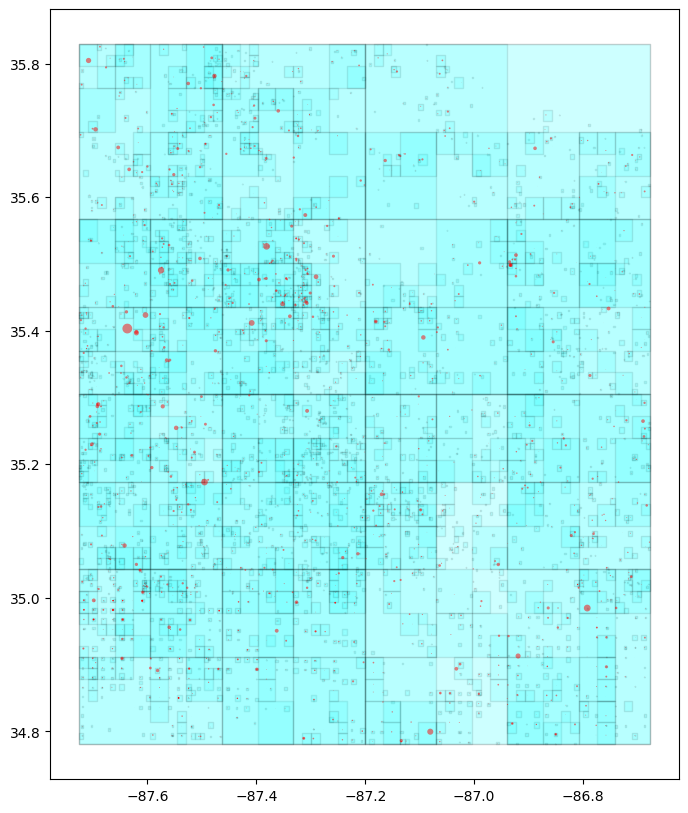

In [9]:
%%time
q_key = partition + '222'
gdf = gdf_file[gdf_file['q_key'].apply(lambda x: x.startswith(q_key))].reset_index(drop=True)

gdf_keys = gdf[['q_key', 'geometry']].drop_duplicates('q_key')
gdf_keys['geometry'] = vs.morton.base4_to_box(gdf_keys['q_key'])
ax = gdf_keys.plot(color='cyan', edgecolor='k', alpha=0.1, aspect='equal', figsize=(10,10))
gdf.plot(ax=ax, color='red', alpha=0.5)

gdf.tail(2)

In [ ]:
# Prune the trees. Two-fold strategy:
# (1) Prune if two levels down, we have more than 4 grand-children.
# (2) Prune if one level down, we have 3 or more leaf nodes.

In [ ]:
# %%time
# # (1) Prune if two levels down, we have more than 4 grand-children.
# df = gdf_concat.copy()
# df['prune_key'] = df['q_key'].apply(lambda x: x[:-2]) # Grandparent
# df['count'] = df[[id_col, 'prune_key', 'q_key']].groupby([id_col, 'prune_key']).transform('count')
# df_prune_nodes = df[df['count']>4][[id_col, 'prune_key']].drop_duplicates().reset_index(drop=True)
# df_prune_nodes['level'] = df_prune_nodes['prune_key'].apply(lambda x: len(x)-2)

# cols = gdf_concat.columns
# for level in reversed(sorted(set(df_prune_nodes['level']))):
#     df1 = gdf_concat[gdf_concat['level']>level]
#     df1['prune_key'] = df1['q_key'].apply(lambda x: x[:level+2])
#     df1 = pandas.concat([df1, gdf_concat[gdf_concat['level']<=level]])
#     # Drop rows based on a "negative" merge
#     gdf_concat = pandas.merge(
#         df1,
#         df_prune_nodes[df_prune_nodes['level']==level][[id_col, 'prune_key']],
#         on=[id_col, 'prune_key'],
#         how="outer",
#         indicator=True
#     )
#     gdf_concat = gdf_concat[gdf_concat['_merge']=='left_only'].reset_index(drop=True)[cols]
# gdf_concat

In [ ]:
id = 48 #88553
ax = vs.gdf_concat[vs.gdf_concat[id_col]==id].plot(color='none')
gdf[gdf[id_col]==id].plot(ax=ax, color='orange')

In [ ]:
id = 48 #88553
ax = vs.gdf_target[vs.gdf_target[id_col]==id].plot(color='none')
gdf[gdf[id_col]==id].plot(ax=ax, color='orange')

In [ ]:
plt.hist(vs.gdf_target.groupby(id_col).count()['geometry'], log=True)
plt.xlabel('Number of children per geometry')
plt.ylabel('Count')
plt.title('Histogram df_target')
plt.show()

In [ ]:
plt.hist(vs.gdf_concat.groupby(id_col).count()['geometry'], log=True)
plt.xlabel('Number of children per geometry')
plt.ylabel('Count')
plt.title('Histogram df_concat')
plt.show()

In [ ]:
# poly = shapely.box(-180, -90, 0, 90)
# gdf1 = vs.gdf_concat[gdf_concat.intersects(poly)]
# gdf1['color'] = numpy.round(numpy.array(gdf1.index/len(gdf1)*19)).astype(int)
# gdf1.plot(gdf1['color'], cmap='tab20', figsize=(20,20))

In [ ]:
poly = shapely.box(-100, 30, -90, 40)
poly = shapely.box(-95, 35, -90, 40)
poly = shapely.box(-98, 38, -96, 40)
#gdf1 = vs.gdf_concat[vs.gdf_concat.intersects(poly)]
gdf1 = vs.gdf_target[vs.gdf_target.intersects(poly)]
gdf2 = gdf[gdf.intersects(poly)]

In [ ]:
gdf1

In [ ]:
ax = gdf1.drop_duplicates(subset='q_key').plot(color='none', figsize=(20,20))
gdf2.plot(ax=ax, color='orange')
plt.show()

In [ ]:
gdf_large = vs.gdf_target[vs.gdf_target.groupby(id_col).transform('count')['geometry']==vs.gdf_target.groupby(id_col).transform('count')['geometry'].max()].reset_index(drop=True)
# gdf_large = vs.gdf_concat[vs.gdf_concat.groupby(id_col).transform('count')['geometry']==vs.gdf_concat.groupby(id_col).transform('count')['geometry'].max()].reset_index(drop=True)
gdf_large.tail(2)

In [ ]:
gdf[gdf[id_col].isin(gdf_large[id_col].unique())]

In [ ]:
gdf_large[id_col].unique()

In [ ]:
ax = gdf_large.plot(color='none')
gdf[gdf[id_col].isin(gdf_large[id_col].unique())].plot(ax=ax, color='orange')

In [ ]:
poly = shapely.box(-180, -90, 0, 90)
poly = shapely.box(-130, 20, -60, 70)
gdf1 = vs.gdf_target[vs.gdf_target.intersects(poly)].reset_index(drop=True)
gdf1['color'] = numpy.round(numpy.array(gdf1.index/len(gdf1)*19)).astype(int)
gdf1.plot(gdf1['color'], cmap='tab20', alpha=0.1, figsize=(20,20))